In [469]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as opt
import math

In [470]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

In [471]:
dta = pd.read_csv("five_stocks.csv")

In [472]:
dta.head()

,Unnamed: 0,Date,Open_GOOGL,High_GOOGL,Low_GOOGL,Close_GOOGL,Volume_GOOGL,Open_NVDA,High_NVDA,Low_NVDA,...,Open_AAPL,High_AAPL,Low_AAPL,Close_AAPL,Volume_AAPL,Open_KO,High_KO,Low_KO,Close_KO,Volume_KO
0,0,1972-06-01 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.38,1.38,1.38,1.38,0.0
1,1,1972-06-02 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.37,1.37,1.37,1.37,0.0
2,2,1972-06-05 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.37,1.37,1.37,1.37,0.0
3,3,1972-06-06 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.36,1.36,1.36,1.36,0.0
4,4,1972-06-07 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.35,1.35,1.35,1.35,0.0


In [473]:
open_cols = [c for c in dta.columns if c.startswith('Open_')]
start_idx = dta[open_cols].notna().all(axis=1).idxmax()
df_filtered = dta.loc[start_idx:].reset_index(drop=True)

In [474]:
df_filtered.head()

,Unnamed: 0,Date,Open_GOOGL,High_GOOGL,Low_GOOGL,Close_GOOGL,Volume_GOOGL,Open_NVDA,High_NVDA,Low_NVDA,...,Open_AAPL,High_AAPL,Low_AAPL,Close_AAPL,Volume_AAPL,Open_KO,High_KO,Low_KO,Close_KO,Volume_KO
0,8141,2004-08-19 16:00:00,2.50,2.60,2.40,2.51,22353092.0,0.10,0.10,0.1,...,0.57,0.57,0.54,0.55,6945541.0,22.18,22.28,21.83,21.96,5256900.0
1,8142,2004-08-20 16:00:00,2.54,2.73,2.51,2.71,11429498.0,0.10,0.10,0.1,...,0.55,0.55,0.54,0.55,5656707.0,21.95,22.11,21.78,22.10,4802600.0
2,8143,2004-08-23 16:00:00,2.77,2.84,2.73,2.74,9140244.0,0.10,0.11,0.1,...,0.55,0.56,0.55,0.56,4547417.0,22.12,22.36,22.00,22.17,4384100.0
3,8144,2004-08-24 16:00:00,2.78,2.79,2.59,2.62,7632224.0,0.11,0.11,0.1,...,0.56,0.57,0.56,0.57,6680922.0,22.25,22.25,22.00,22.01,4849900.0
4,8145,2004-08-25 16:00:00,2.62,2.70,2.60,2.65,4599110.0,0.10,0.11,0.1,...,0.57,0.59,0.57,0.59,9032543.0,21.99,22.23,21.86,22.17,4867200.0


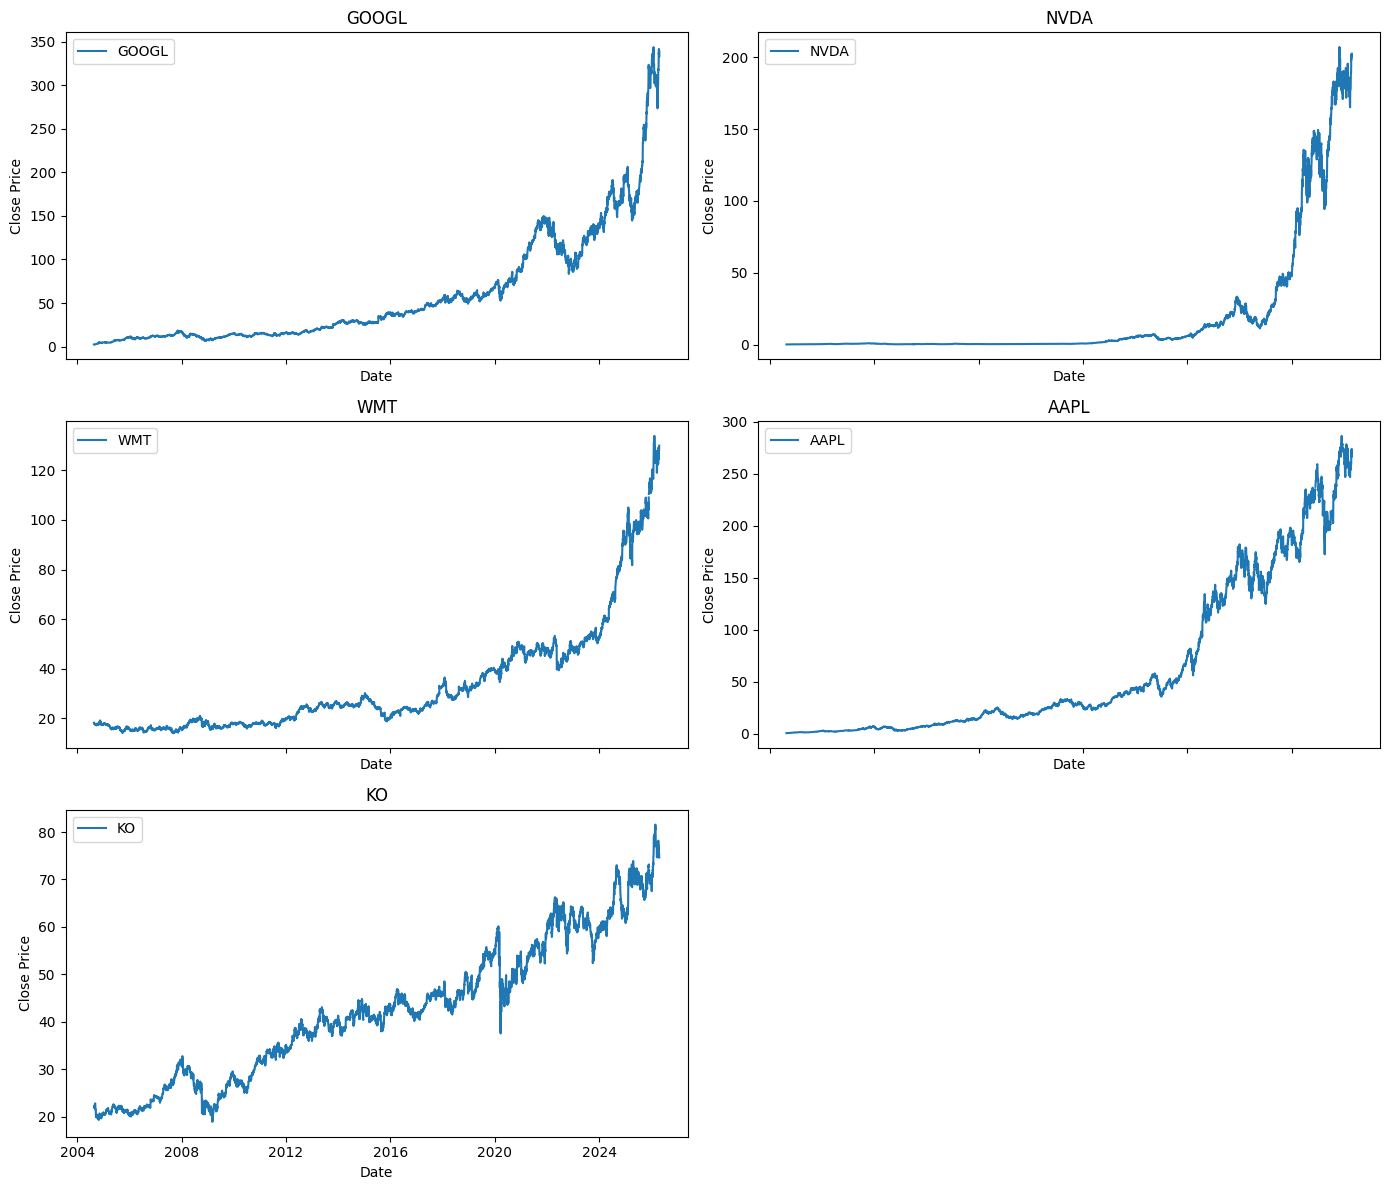

In [475]:
tickers = [c.replace('Close_', '') for c in df_filtered.columns if c.startswith('Close_')]
df_filtered['Date'] = pd.to_datetime(df_filtered['Date'])

ncols = 2
nrows = len(tickers) // ncols + (len(tickers) % ncols > 0)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, tickers):
    ax.plot(df_filtered['Date'], df_filtered[f'Close_{t}'], label=t)
    ax.set_ylabel('Close Price')
    ax.set_xlabel("Date")
    ax.legend(loc='upper left')
    ax.set_title(t)

for ax in axes[len(tickers):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [517]:
close_cols = [f'Close_{t}' for t in tickers]
increments = df_filtered[close_cols].diff().dropna()
Sigma = increments.corr()
print(Sigma)

             Close_GOOGL  Close_NVDA  Close_WMT  Close_AAPL  Close_KO
Close_GOOGL     1.000000    0.367528   0.144689    0.495660  0.136635
Close_NVDA      0.367528    1.000000   0.025878    0.317963 -0.082830
Close_WMT       0.144689    0.025878   1.000000    0.241437  0.321602
Close_AAPL      0.495660    0.317963   0.241437    1.000000  0.227735
Close_KO        0.136635   -0.082830   0.321602    0.227735  1.000000


In [525]:
Sigma_tens = torch.tensor(Sigma.values,dtype=torch.float32)
Sigma_tilde = torch.linalg.cholesky(Sigma_tens)
d,_ = Sigma_tens.shape
idx = torch.tril_indices(d, d)
vech_sigma = Sigma_tens[idx[0], idx[1]]

In [526]:
print(Sigma_tens)
print(Sigma_tilde)

print(vech_sigma)

tensor([[ 1.0000,  0.3675,  0.1447,  0.4957,  0.1366],
        [ 0.3675,  1.0000,  0.0259,  0.3180, -0.0828],
        [ 0.1447,  0.0259,  1.0000,  0.2414,  0.3216],
        [ 0.4957,  0.3180,  0.2414,  1.0000,  0.2277],
        [ 0.1366, -0.0828,  0.3216,  0.2277,  1.0000]])
tensor([[ 1.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.3675,  0.9300,  0.0000,  0.0000,  0.0000],
        [ 0.1447, -0.0294,  0.9890,  0.0000,  0.0000],
        [ 0.4957,  0.1460,  0.1759,  0.8379,  0.0000],
        [ 0.1366, -0.1431,  0.3009,  0.1527,  0.9203]])
tensor([ 1.0000,  0.3675,  1.0000,  0.1447,  0.0259,  1.0000,  0.4957,  0.3180,
         0.2414,  1.0000,  0.1366, -0.0828,  0.3216,  0.2277,  1.0000])


In [608]:
def log_V(theta, X):
    """
    theta : (n, N-1, d)
    X : (n, N, d)
    """
    Delta_X = X[:, 1:, :] - X[:, :-1, :]
    inner = torch.sum(theta * Delta_X, dim=2)  # (n, N-1)
    return torch.sum(torch.log(1 + inner), dim=1)  # (n,)

def g(theta,X,T):
    return (1/T) * torch.mean(log_V(theta,X))

def UO(beta, sigma_tilde, N, T, n_paths=1, seed=0):
    torch.manual_seed(seed)
    d, _ = sigma_tilde.shape
    dt = T / N
    states = [torch.ones(size=(n_paths, d))]
    for t in range(N - 1):
        dW = math.sqrt(dt) * torch.randn(size=(n_paths, d))
        x_new = states[t] - (states[t] @ beta.T) * dt + (dW @ sigma_tilde.T)
        states.append(x_new)
    return torch.stack(states, dim=1)

In [685]:
class Loss_multi:
    def __init__(self, N, T, Sigma_tens, Sigma_tilde, lambda1,lambda2, n_paths=1, seed=0):
        self.N = N
        self.T = T
        self.lambda1 = lambda1
        self.lambda2 = lambda2

        self.Sigma_tilde = Sigma_tilde
        self.Sigma_tens = Sigma_tens
        self.n_paths = n_paths
        self.seed = seed

    def _simulate_and_act(self, f_agent, beta):
        X = UO(beta, self.Sigma_tilde, self.N, self.T, self.n_paths, seed=self.seed)
        d = X.shape[2]
        theta = f_agent(X[:, :-1, :].reshape(-1, d)).reshape(self.n_paths, self.N - 1, d)
        return theta, X

    def L_agent(self, f_agent, beta):
        theta, X = self._simulate_and_act(f_agent, beta)
        return -g(theta, X, self.T)

    # def L_adv(self, f_agent, beta):
    #     theta, X = self._simulate_and_act(f_agent, beta)
    #     return g(theta, X, self.T) + self.lambda1 * torch.linalg.norm(self.Sigma_tens @ beta.T + beta @ self.Sigma_tens - self.Sigma_tens) ** 2
    
    
    def L_adv(self, f_agent, beta):
        theta, X = self._simulate_and_act(f_agent, beta)
        lyap = torch.linalg.norm(self.Sigma_tens @ beta.T + beta @ self.Sigma_tens - self.Sigma_tens) ** 2
        eigvals = torch.linalg.eigvalsh(beta)
        stability = torch.sum(torch.relu(0.2-eigvals) ** 2)
        return g(theta, X, self.T) + self.lambda1 * lyap + self.lambda2 * stability

In [686]:
def nets():
    SEED = 0
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    f_agent = nn.Sequential(
        nn.Linear(d,math.ceil(0.5*d)),
        nn.ReLU(),
        nn.Linear(math.ceil(0.5*d),math.ceil(math.sqrt(d))),
        nn.ReLU(),
        nn.Linear(math.ceil(math.sqrt(d)),d)
    )

    f_adv = nn.Sequential(
        nn.Linear(int((d*(d+1))/2),d),
        nn.ReLU(),
        nn.Linear(d,math.ceil(0.5*d)),
        nn.ReLU(),
        nn.Linear(math.ceil(0.5*d),d**2)
    )
    print(f_agent)
    print(f_adv)
    return f_agent,f_adv


In [687]:
N = 100; n_paths = 100; T = 1; seed=0; lambda1 = 10; lambda2=10
f_agent,f_adv = nets()


Sequential(
  (0): Linear(in_features=5, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=3, bias=True)
  (3): ReLU()
  (4): Linear(in_features=3, out_features=5, bias=True)
)
Sequential(
  (0): Linear(in_features=15, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=3, bias=True)
  (3): ReLU()
  (4): Linear(in_features=3, out_features=25, bias=True)
)


In [688]:
optimizer_agent = opt.SGD(f_agent.parameters(),lr=1e-3)    
optimizer_adv = opt.SGD(f_adv.parameters(),lr=1e-3)
epochs = 1000
L_coll = []

for ep in range(epochs):
    beta = f_adv(vech_sigma).reshape(d, d)
    L = Loss_multi(N=N,T=T,Sigma_tens=Sigma_tens,Sigma_tilde=Sigma_tilde,lambda1=lambda1,lambda2=lambda2,n_paths=n_paths,seed=ep)

    optimizer_agent.zero_grad()
    loss_agent = L.L_agent(f_agent , beta)
    loss_agent.backward()
    optimizer_agent.step()

  

    beta = f_adv(vech_sigma).reshape(d, d)

    optimizer_adv.zero_grad()
    loss_adv = L.L_adv(f_agent, beta)
    loss_adv.backward()
    optimizer_adv.step()

    L_coll.append(-loss_agent.item())

    if ep % (int(epochs / 10)) == 0:
        print(f"Progress: {ep}/{epochs}, g: {-loss_agent.item():.4f}")
        print("Lyapunov violation:", torch.linalg.norm(Sigma_tens @ beta.T + beta @ Sigma_tens - Sigma_tens).item())
        print("Eigenvalues:", torch.linalg.eigvalsh(beta))

Progress: 0/1000, g: -0.7403
Lyapunov violation: 4.777561187744141
Eigenvalues: tensor([-1.3775, -0.2366, -0.1406,  0.3910,  0.9319],
       grad_fn=<LinalgEighBackward0>)
Progress: 100/1000, g: -0.1574
Lyapunov violation: 0.11768510937690735
Eigenvalues: tensor([-0.0843,  0.4206,  0.5161,  0.6811,  1.0253],
       grad_fn=<LinalgEighBackward0>)
Progress: 200/1000, g: -0.0501
Lyapunov violation: 0.12951412796974182
Eigenvalues: tensor([-0.1262,  0.4512,  0.5363,  0.6964,  1.0098],
       grad_fn=<LinalgEighBackward0>)
Progress: 300/1000, g: 0.0560
Lyapunov violation: 0.14415347576141357
Eigenvalues: tensor([-0.1703,  0.4733,  0.5413,  0.7190,  1.0043],
       grad_fn=<LinalgEighBackward0>)
Progress: 400/1000, g: 0.0773
Lyapunov violation: 0.15919971466064453
Eigenvalues: tensor([-0.2122,  0.4820,  0.5412,  0.7514,  1.0071],
       grad_fn=<LinalgEighBackward0>)
Progress: 500/1000, g: 0.1306
Lyapunov violation: 0.1730065643787384
Eigenvalues: tensor([-0.2489,  0.4724,  0.5408,  0.7908, 

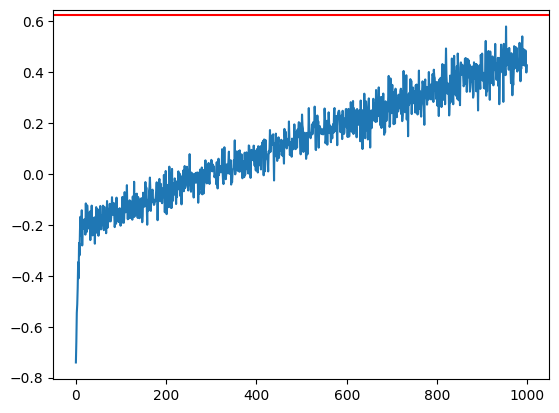

In [695]:
plt.plot(L_coll)
plt.axhline(y=d/8,color='red')
plt.show()